# 02 — RealNVP from scratch on a 2D Gaussian mixture

Goal: validate the `bg.flows.RealNVP` implementation by maximum-likelihood-fitting a known target distribution. This is the **forward-KL** training regime (mode-covering, needs target samples). In M5 we switch to **reverse-KL** training where only the energy `u(x)` is required.

Checks for this notebook:

1. The MLE objective decreases steadily.
2. Sampled points cover all 4 modes (no mode collapse).
3. Model log-density matches a kernel density estimate of the target.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import trange

from bg.flows import RealNVP, GaussianPrior, FlowModel

torch.manual_seed(0)
np.random.seed(0)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device={device}')

/Users/manumartinm/Documents/proyectos/boltzmann_generators/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device=mps


## 1. Target distribution — 4-mode 2D Gaussian mixture

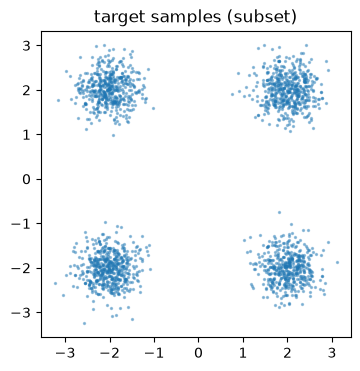

In [2]:
MODES = torch.tensor([
    [ 2.0,  2.0],
    [-2.0,  2.0],
    [-2.0, -2.0],
    [ 2.0, -2.0],
])
SIGMA = 0.35
WEIGHTS = torch.ones(len(MODES)) / len(MODES)

def sample_target(n: int) -> torch.Tensor:
    idx = torch.multinomial(WEIGHTS, n, replacement=True)
    centers = MODES[idx]
    return centers + SIGMA * torch.randn(n, 2)

x_train = sample_target(20_000)
x_val = sample_target(2_000)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x_train[:2000, 0], x_train[:2000, 1], s=2, alpha=0.4)
ax.set_aspect('equal'); ax.set_title('target samples (subset)')
plt.show()

## 2. Build flow model

In [3]:
flow = RealNVP(dim=2, num_layers=8, hidden_dim=64, num_hidden=2, mask='halves')
prior = GaussianPrior(2)
model = FlowModel(prior, flow).to(device)
print(f'#params: {sum(p.numel() for p in model.parameters()):,}')

#params: 36,896


## 3. Train with MLE (forward KL)

In [4]:
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
batch_size = 512
n_steps = 3000
hist = {'train_nll': [], 'val_nll': []}

x_train_dev = x_train.to(device)
x_val_dev = x_val.to(device)

pbar = trange(n_steps)
for step in pbar:
    idx = torch.randint(0, x_train_dev.shape[0], (batch_size,), device=device)
    xb = x_train_dev[idx]
    loss = model.nll(xb)
    opt.zero_grad(); loss.backward(); opt.step()

    hist['train_nll'].append(loss.item())
    if step % 100 == 0:
        with torch.no_grad():
            val = model.nll(x_val_dev).item()
        hist['val_nll'].append((step, val))
        pbar.set_postfix(train=f'{loss.item():.3f}', val=f'{val:.3f}')

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:04<?, ?it/s, train=5.963, val=5.474]

  0%|          | 1/3000 [00:04<3:47:51,  4.56s/it, train=5.963, val=5.474]

  0%|          | 10/3000 [00:04<16:54,  2.95it/s, train=5.963, val=5.474] 

  1%|          | 16/3000 [00:04<09:23,  5.30it/s, train=5.963, val=5.474]

...

 99%|█████████▉| 2964/3000 [00:39<00:00, 93.89it/s, train=2.250, val=2.232]

 99%|█████████▉| 2974/3000 [00:39<00:00, 92.95it/s, train=2.250, val=2.232]

100%|█████████▉| 2985/3000 [00:39<00:00, 96.43it/s, train=2.250, val=2.232]

100%|█████████▉| 2996/3000 [00:40<00:00, 99.22it/s, train=2.250, val=2.232]

100%|██████████| 3000/3000 [00:40<00:00, 74.78it/s, train=2.250, val=2.232]

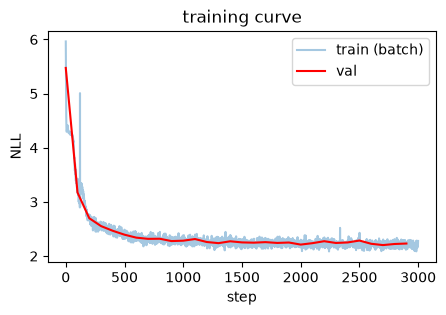

In [5]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(hist['train_nll'], alpha=0.4, label='train (batch)')
xs, ys = zip(*hist['val_nll'])
ax.plot(xs, ys, 'r-', label='val')
ax.set_xlabel('step'); ax.set_ylabel('NLL'); ax.legend(); ax.set_title('training curve')
plt.show()

## 4. Compare samples & density

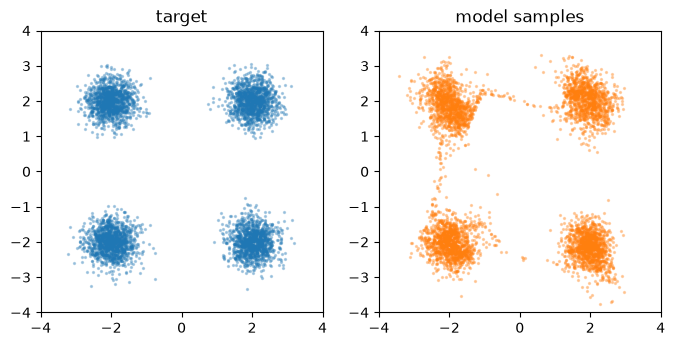

In [6]:
with torch.no_grad():
    x_model, _ = model.sample(5000, device=device)
x_model = x_model.cpu()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(x_train[:5000, 0], x_train[:5000, 1], s=2, alpha=0.3)
axes[0].set_title('target'); axes[0].set_aspect('equal')
axes[1].scatter(x_model[:, 0], x_model[:, 1], s=2, alpha=0.3, color='C1')
axes[1].set_title('model samples'); axes[1].set_aspect('equal')
for ax in axes:
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.show()

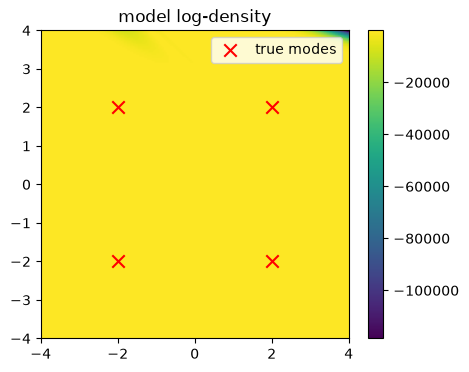

In [7]:
# log-density heatmap
grid_n = 200
xs = torch.linspace(-4, 4, grid_n)
ys = torch.linspace(-4, 4, grid_n)
gx, gy = torch.meshgrid(xs, ys, indexing='xy')
grid = torch.stack([gx.flatten(), gy.flatten()], dim=-1).to(device)
with torch.no_grad():
    log_p = model.log_prob(grid).cpu().reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(log_p.numpy(), extent=(-4, 4, -4, 4), origin='lower', cmap='viridis')
ax.scatter(MODES[:, 0], MODES[:, 1], marker='x', color='red', s=80, label='true modes')
ax.set_title('model log-density')
plt.colorbar(im, ax=ax); ax.legend()
plt.show()

## 5. Verification

Expected:
- All 4 modes are populated in model samples (no collapse).
- log-density heatmap has 4 clear peaks at `MODES`.
- Validation NLL plateaus around the entropy of the target mixture.

If a mode is missing, train longer or increase `num_layers`. If the density looks like one big blob, the masks aren't mixing dims — try `mask='alternating'` (works for dim≥4; for dim=2 halves is essentially equivalent).

Next: **M4** — derive the reverse-KL ("KL by energy") loss in `theory/03_boltzmann_generators.md`, then in M5 train the same flow on the double-well *without* using samples, only the energy function.